In [ ]:
!pip install transformers pandas numpy matplotlib seaborn networkx tqdm

In [2]:
import pandas as pd
import json
import re
import pickle
from collections import Counter
from tqdm import tqdm
import numpy as np
import torch
import os
import matplotlib.pyplot as plt
from itertools import combinations
import seaborn as sns
import networkx as nx

def save_pkl(tgt_list, svg_path):
    with open(svg_path, "wb") as f:
        pickle.dump(tgt_list, f)

def load_pkl(path) :
    with open(path, "rb") as f:
        data = pickle.load(f)
    return data

In [3]:
# Load SPARK dataset
spark_df = pd.read_csv("./SPARK_experiment_dataset_1635.csv")
spark_df.head()

,Index,sentence_ko,sentence_en,topic_label,emotion
0,0,SBS 기자님 술냄새가.,"SBS reporter, smell like booze.",Venting,neutral
1,3,대통령보다 2찍 기초수급자들이 더 멍청하다는것에 대해놀랐다.,I’m honestly shocked that the people who voted...,People,curiosity
2,4,민주당 척결,Purge the Democratic Party.,Politics & Economics,disapproval
3,5,위헌했다고 소명하는건가,Is that your excuse? That it’s unconstitutional?,Others,annoyance
4,6,여야를떠나 합법적인 모든수단은 어떤이유든핑계든 수용되지만불법적인 수단은 절대 용납될수없다,"Regardless of party, all legal means are justi...",Others,disgust


In [4]:
# Check unique emotions in the dataset
unique_emotions = spark_df['emotion'].unique()
print("Unique emotions:", unique_emotions)
print("Number of unique emotions:", len(unique_emotions))

Unique emotions: ['neutral' 'curiosity' 'disapproval' 'annoyance' 'disgust' 'amusement'
 'approval' 'caring' 'anger' 'nervousness' 'disappointment' 'confusion'
 'surprise' 'gratitude' 'admiration' 'relief' 'sadness' 'realization'
 'excitement' 'joy' 'fear' 'optimism' 'desire' 'embarrassment' 'remorse'
 'pride']
Number of unique emotions: 26


In [5]:
# Create emotion mapping (similar to the original notebook)
# Map emotions to indices for correlation analysis
emotion_to_idx = {emotion: idx for idx, emotion in enumerate(sorted(unique_emotions))}
idx_to_emotion = {idx: emotion for emotion, idx in emotion_to_idx.items()}

print("Emotion mapping:")
for emotion, idx in emotion_to_idx.items():
    print(f"{idx}: {emotion}")

Emotion mapping:
0: admiration
1: amusement
2: anger
3: annoyance
4: approval
5: caring
6: confusion
7: curiosity
8: desire
9: disappointment
10: disapproval
11: disgust
12: embarrassment
13: excitement
14: fear
15: gratitude
16: joy
17: nervousness
18: neutral
19: optimism
20: pride
21: realization
22: relief
23: remorse
24: sadness
25: surprise


In [6]:
# Process the data to create emotion count matrix
# Group by some identifier if needed, or treat each row as a separate instance

# For this dataset, each row represents a sentence with its emotion
# We'll create a matrix where each row represents a sentence and columns are emotion counts

emotion_columns = sorted(unique_emotions)
emotion_df = pd.DataFrame(0, index=spark_df.index, columns=emotion_columns)

for idx, row in spark_df.iterrows():
    emotion = row['emotion']
    if emotion in emotion_columns:
        emotion_df.loc[idx, emotion] = 1  # Binary encoding - each sentence has one primary emotion

emotion_df.head()

,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,desire,disappointment,...,joy,nervousness,neutral,optimism,pride,realization,relief,remorse,sadness,surprise
0,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Add topic information if needed
spark_with_emotions = pd.concat([spark_df, emotion_df], axis=1)
spark_with_emotions.head()

Emotion distribution:
anger             311
annoyance         210
neutral           182
curiosity         173
disapproval       161
amusement         134
approval           69
disgust            64
confusion          53
surprise           45
realization        40
disappointment     33
nervousness        28
fear               26
admiration         20
embarrassment      17
caring             17
desire             13
sadness            13
optimism            8
excitement          7
gratitude           6
relief              2
joy                 1
pride               1
remorse             1
dtype: int64


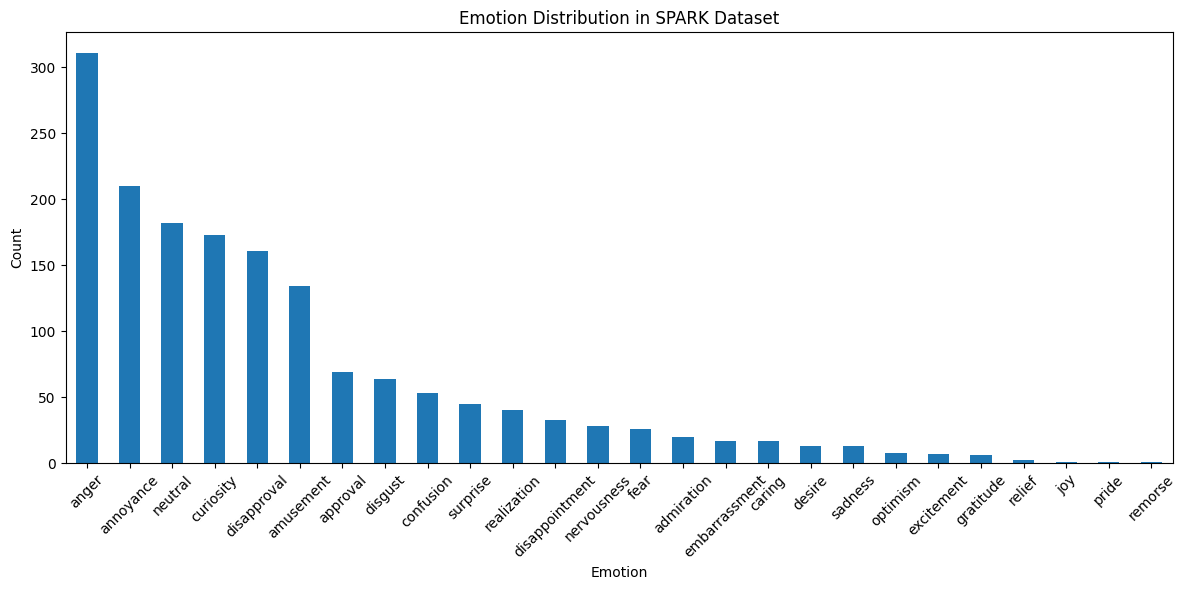

In [7]:
# Analyze emotion distribution
emotion_counts = emotion_df.sum().sort_values(ascending=False)
print("Emotion distribution:")
print(emotion_counts)

# Visualize emotion distribution
plt.figure(figsize=(12, 6))
emotion_counts.plot(kind='bar')
plt.title('Emotion Distribution in SPARK Dataset')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

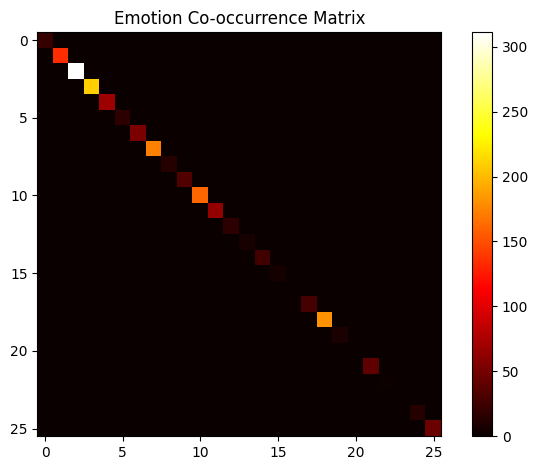

In [8]:
# Create co-occurrence matrix (following the original framework)
def get_heatmap(df, svg_name=None):
    df_np = df.to_numpy()
    df_trans = df_np.transpose()
    heatmap_prep = np.matmul(df_trans, df_np)

    plt.imshow(heatmap_prep, cmap="hot")
    plt.colorbar()
    plt.title('Emotion Co-occurrence Matrix')
    plt.tight_layout()
    if svg_name is not None:
        plt.savefig(svg_name)
    plt.show()

get_heatmap(emotion_df)

In [9]:
# Calculate emotion co-occurrence pairs (following original framework)
def extract_nonzero(emo_list):
    return [key for key, val in enumerate(emo_list) if val != 0]

if __name__ == '__main__':
    final_list = []
    only_emo_list = []
    
    for i in tqdm(range(len(emotion_df)), desc="Processing emotion co-occurrences"):
        # Each row represents emotions in a sentence
        temp_emo_list = emotion_df.iloc[i].to_list()
        non_zero_idx = extract_nonzero(temp_emo_list)
        only_emo_list.extend(non_zero_idx)
        
        # For co-occurrence, since each sentence has only one emotion in this dataset,
        # we need to think differently. Let's group by some other factor or treat
        # sentences as having multiple emotions if they appear in similar contexts.
        
        # For now, let's create pairs within the same topic or just analyze individual emotions
        
    print("Emotion indices found:", set(only_emo_list))

Processing emotion co-occurrences: 100%|██████████| 1635/1635 [00:00<00:00, 125921.54it/s]

Emotion indices found: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25}


In [10]:
# Since this dataset has one emotion per sentence, let's analyze by topic
# Group emotions by topic to see co-occurrence patterns

topic_emotion_counts = spark_df.groupby(['topic_label', 'emotion']).size().unstack(fill_value=0)
topic_emotion_counts

emotion,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,desire,disappointment,...,joy,nervousness,neutral,optimism,pride,realization,relief,remorse,sadness,surprise
topic_label,,,,,,,,,,,,,,,,,,,,,
North Korea,2,8,24,13,7,2,1,11,1,1,...,0,2,19,0,0,1,0,0,1,5
Others,4,14,41,43,10,2,7,38,0,4,...,0,2,21,3,0,6,0,0,2,9
People,3,46,88,62,25,5,15,48,3,13,...,0,5,42,2,0,7,1,0,6,10
Politics & Economics,1,5,24,13,2,2,2,6,0,1,...,0,2,14,0,0,5,0,0,0,3
Punishment,3,13,30,23,4,2,5,14,3,1,...,0,6,17,0,1,4,0,0,0,6
Venting,7,48,104,56,21,4,23,56,6,13,...,1,11,69,3,0,17,1,1,4,12


In [11]:
# Create correlation matrix for emotions across topics
emotion_corr = emotion_df.corr()
emotion_corr

,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,desire,disappointment,...,joy,nervousness,neutral,optimism,pride,realization,relief,remorse,sadness,surprise
admiration,1.000000,-0.033250,-0.053934,-0.042720,-0.023359,-0.011407,-0.020369,-0.038281,-0.009963,-0.015972,...,-0.002753,-0.014689,-0.039385,-0.007803,-0.002753,-0.017623,-0.003894,-0.002753,-0.009963,-0.018721
amusement,-0.033250,1.000000,-0.144810,-0.114700,-0.062718,-0.030626,-0.054689,-0.102781,-0.026749,-0.042883,...,-0.007392,-0.039440,-0.105746,-0.020951,-0.007392,-0.047316,-0.010456,-0.007392,-0.026749,-0.050265
anger,-0.053934,-0.144810,1.000000,-0.186054,-0.101734,-0.049679,-0.088710,-0.166719,-0.043389,-0.069560,...,-0.011990,-0.063975,-0.171530,-0.033985,-0.011990,-0.076751,-0.016961,-0.011990,-0.043389,-0.081535
annoyance,-0.042720,-0.114700,-0.186054,1.000000,-0.080581,-0.039349,-0.070265,-0.132054,-0.034368,-0.055097,...,-0.009497,-0.050673,-0.135864,-0.026919,-0.009497,-0.060793,-0.013435,-0.009497,-0.034368,-0.064582
approval,-0.023359,-0.062718,-0.101734,-0.080581,1.000000,-0.021516,-0.038421,-0.072207,-0.018792,-0.030127,...,-0.005193,-0.027708,-0.074290,-0.014719,-0.005193,-0.033241,-0.007346,-0.005193,-0.018792,-0.035313
caring,-0.011407,-0.030626,-0.049679,-0.039349,-0.021516,1.000000,-0.018762,-0.035260,-0.009177,-0.014712,...,-0.002536,-0.013530,-0.036278,-0.007188,-0.002536,-0.016232,-0.003587,-0.002536,-0.009177,-0.017244
confusion,-0.020369,-0.054689,-0.088710,-0.070265,-0.038421,-0.018762,1.000000,-0.062963,-0.016386,-0.026270,...,-0.004528,-0.024160,-0.064779,-0.012835,-0.004528,-0.028986,-0.006406,-0.004528,-0.016386,-0.030792
curiosity,-0.038281,-0.102781,-0.166719,-0.132054,-0.072207,-0.035260,-0.062963,1.000000,-0.030796,-0.049371,...,-0.008510,-0.045407,-0.121745,-0.024121,-0.008510,-0.054475,-0.012038,-0.008510,-0.030796,-0.057870
desire,-0.009963,-0.026749,-0.043389,-0.034368,-0.018792,-0.009177,-0.016386,-0.030796,1.000000,-0.012849,...,-0.002215,-0.011817,-0.031685,-0.006278,-0.002215,-0.014177,-0.003133,-0.002215,-0.008015,-0.015061
disappointment,-0.015972,-0.042883,-0.069560,-0.055097,-0.030127,-0.014712,-0.026270,-0.049371,-0.012849,1.000000,...,-0.003551,-0.018945,-0.050796,-0.010064,-0.003551,-0.022729,-0.005023,-0.003551,-0.012849,-0.024145


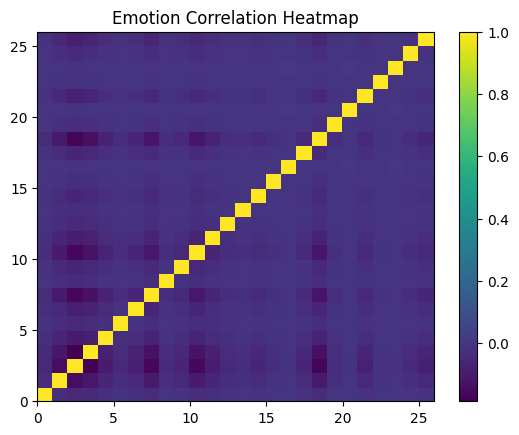

In [12]:
# Visualize correlation heatmap
def get_corr_graph(data, svg_name=None):
    heatmap = plt.pcolor(data)
    plt.rcParams["figure.figsize"] = [12, 10]
    plt.colorbar(heatmap)
    plt.title('Emotion Correlation Heatmap')
    if svg_name is not None:
        plt.savefig(svg_name)
    plt.show()

get_corr_graph(emotion_corr, "spark_emotion_corr_heatmap.png")

/var/folders/1k/9zscxwr53576ysrq8v5ym4qc0000gn/T/ipykernel_61204/1549263142.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.93])


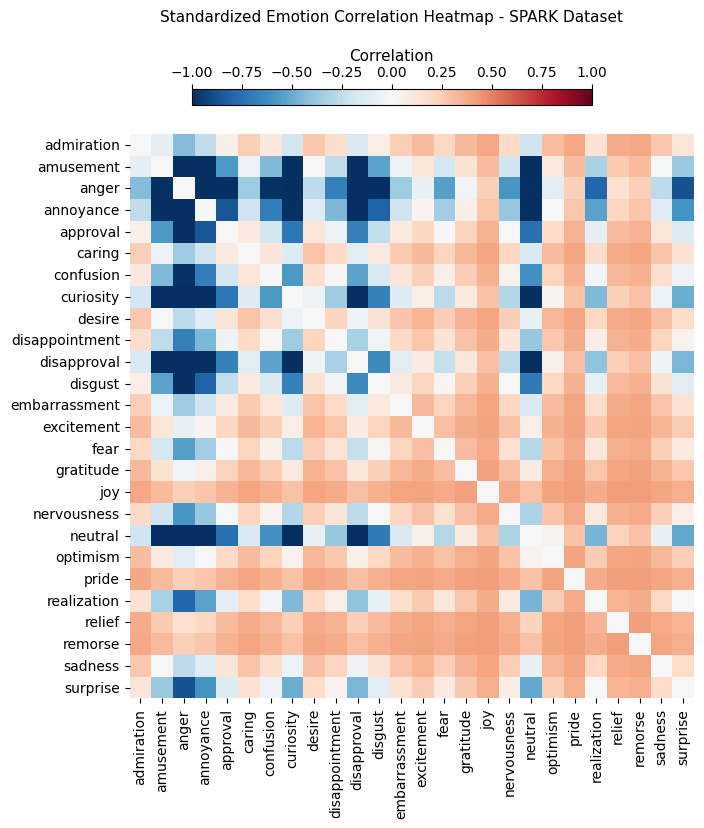

In [13]:
# Create standardized correlation heatmap (following original framework)
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

corr = emotion_df.corr()
corr_no_diag = corr.copy()
np.fill_diagonal(corr_no_diag.values, np.nan)
mean_val = np.nanmean(corr_no_diag.values)
std_val = np.nanstd(corr_no_diag.values)
scaled_corr = (corr - mean_val) / std_val
scaled_corr = np.clip(scaled_corr, -2, 2) / 2
np.fill_diagonal(scaled_corr.values, 0)

# Create figure and heatmap
fig, ax = plt.subplots(figsize=(10, 8))
heatmap = sns.heatmap(
    scaled_corr,
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    cbar=False,
    ax=ax
)

# Add colorbar
cbar_ax = fig.add_axes([0.3, 0.91, 0.4, 0.02])
cbar = fig.colorbar(
    heatmap.get_children()[0],
    cax=cbar_ax,
    orientation='horizontal'
)
cbar.set_label("Correlation", fontsize=11)
cbar.ax.xaxis.set_label_position('top')
cbar.ax.xaxis.set_ticks_position('top')

plt.suptitle("Standardized Emotion Correlation Heatmap - SPARK Dataset", y=1.03, fontsize=11)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("spark_standardized_corr_heatmap.png", dpi=300)
plt.show()

In [14]:
# Analyze correlations
corr = emotion_df.corr()

# Mask diagonal
np.fill_diagonal(corr.values, np.nan)

min_corr = corr.min().min()
max_corr = corr.max().max()

print("Minimum correlation:", min_corr)
print("Maximum correlation:", max_corr)

corr_pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()

# Sort by correlation value
print("Top 10 strongest correlations:")
print(corr_pairs.sort_values(ascending=False).head(10))

print("\nTop 10 weakest correlations:")
print(corr_pairs.sort_values().head(10))

Minimum correlation: -0.18605374541732
Maximum correlation: -0.0006119951040391692
Top 10 strongest correlations:
pride       remorse   -0.000612
joy         pride     -0.000612
            remorse   -0.000612
pride       relief    -0.000866
relief      remorse   -0.000866
joy         relief    -0.000866
gratitude   joy       -0.001501
            pride     -0.001501
            remorse   -0.001501
excitement  joy       -0.001622
dtype: float64

Top 10 weakest correlations:
anger        annoyance     -0.186054
             neutral       -0.171530
             curiosity     -0.166719
             disapproval   -0.160177
amusement    anger         -0.144810
annoyance    neutral       -0.135864
             curiosity     -0.132054
             disapproval   -0.126872
curiosity    neutral       -0.121745
disapproval  neutral       -0.116968
dtype: float64


In [15]:
# Create network graph (following original framework)
# Since we have single emotions per sentence, we'll create a network based on topic co-occurrence

# First, let's see emotions by topic
topic_emotion_matrix = pd.crosstab(spark_df['topic_label'], spark_df['emotion'])
topic_emotion_matrix

emotion,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,desire,disappointment,...,joy,nervousness,neutral,optimism,pride,realization,relief,remorse,sadness,surprise
topic_label,,,,,,,,,,,,,,,,,,,,,
North Korea,2,8,24,13,7,2,1,11,1,1,...,0,2,19,0,0,1,0,0,1,5
Others,4,14,41,43,10,2,7,38,0,4,...,0,2,21,3,0,6,0,0,2,9
People,3,46,88,62,25,5,15,48,3,13,...,0,5,42,2,0,7,1,0,6,10
Politics & Economics,1,5,24,13,2,2,2,6,0,1,...,0,2,14,0,0,5,0,0,0,3
Punishment,3,13,30,23,4,2,5,14,3,1,...,0,6,17,0,1,4,0,0,0,6
Venting,7,48,104,56,21,4,23,56,6,13,...,1,11,69,3,0,17,1,1,4,12


In [16]:
# Create emotion co-occurrence within topics
# For each topic, find which emotions appear together

emotion_pairs = []
for topic in spark_df['topic_label'].unique():
    topic_data = spark_df[spark_df['topic_label'] == topic]
    topic_emotions = topic_data['emotion'].tolist()
    
    # Get unique emotions in this topic
    unique_topic_emotions = list(set(topic_emotions))
    
    # Create pairs of emotions that appear in the same topic
    if len(unique_topic_emotions) > 1:
        pairs = list(combinations(sorted(unique_topic_emotions), 2))
        emotion_pairs.extend(pairs)

pair_counter = Counter(emotion_pairs)
print("Emotion pairs by topic:")
for pair, count in pair_counter.most_common(10):
    print(f"{pair}: {count}")

Emotion pairs by topic:
('admiration', 'amusement'): 6
('admiration', 'anger'): 6
('admiration', 'annoyance'): 6
('admiration', 'approval'): 6
('admiration', 'caring'): 6
('admiration', 'confusion'): 6
('admiration', 'curiosity'): 6
('admiration', 'disappointment'): 6
('admiration', 'disapproval'): 6
('admiration', 'disgust'): 6


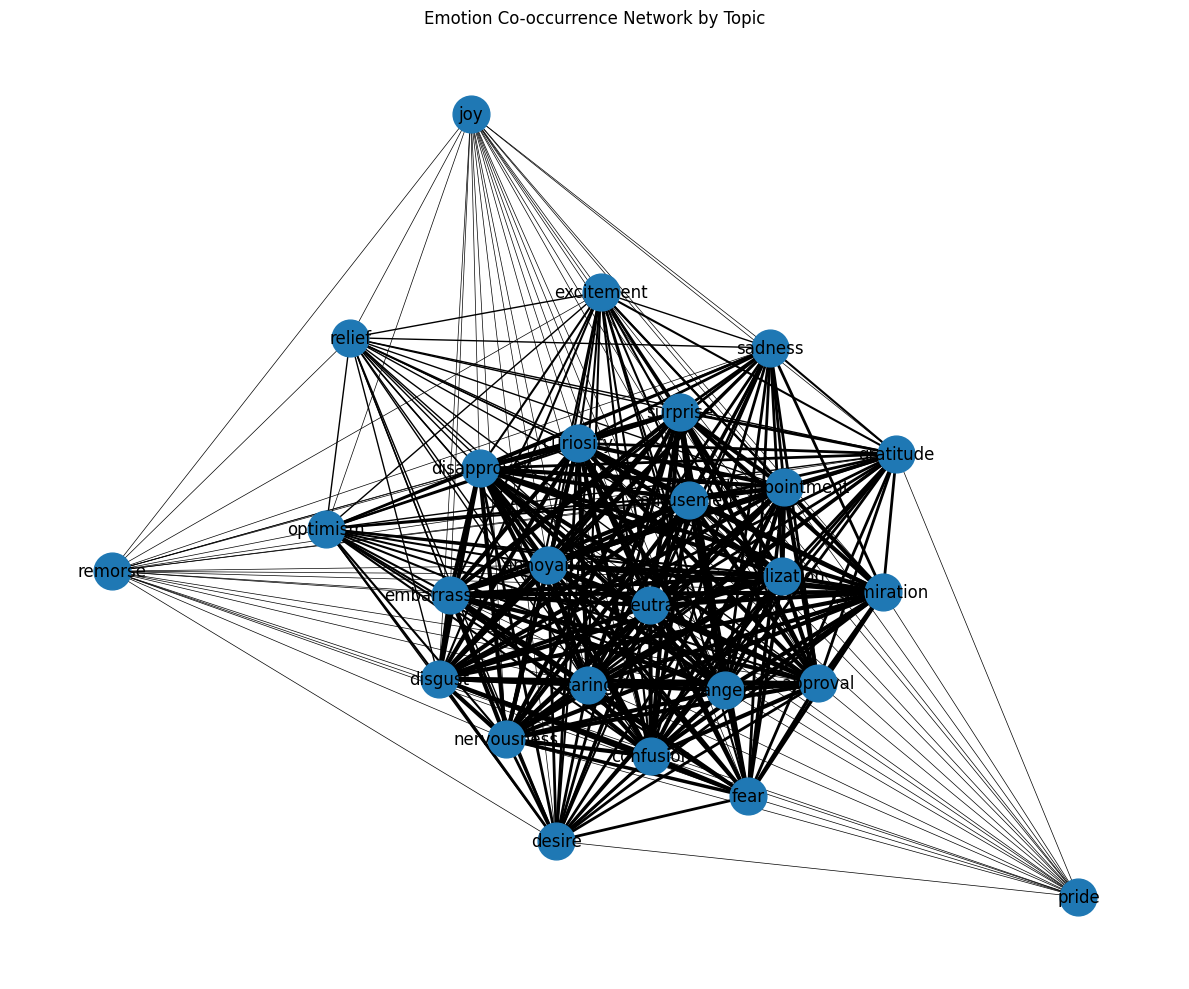

In [17]:
# Create network graph
import networkx as nx

if pair_counter:
    G = nx.Graph()
    for pair, weight in pair_counter.items():
        G.add_edge(pair[0], pair[1], weight=weight)

    # Draw the network
    plt.figure(figsize=(12, 10))
    pos = nx.spring_layout(G, seed=42)
    
    # Draw nodes
    nx.draw_networkx_nodes(G, pos, node_size=700)
    
    # Draw edges with weights
    edges = G.edges()
    weights = [G[u][v]['weight'] for u, v in edges]
    
    nx.draw_networkx_edges(G, pos, width=[w*0.5 for w in weights])
    nx.draw_networkx_labels(G, pos, font_size=12)
    
    plt.title('Emotion Co-occurrence Network by Topic')
    plt.axis('off')
    plt.tight_layout()
    plt.savefig('spark_emotion_network.png', dpi=300)
    plt.show()
else:
    print("No emotion pairs found for network visualization.")

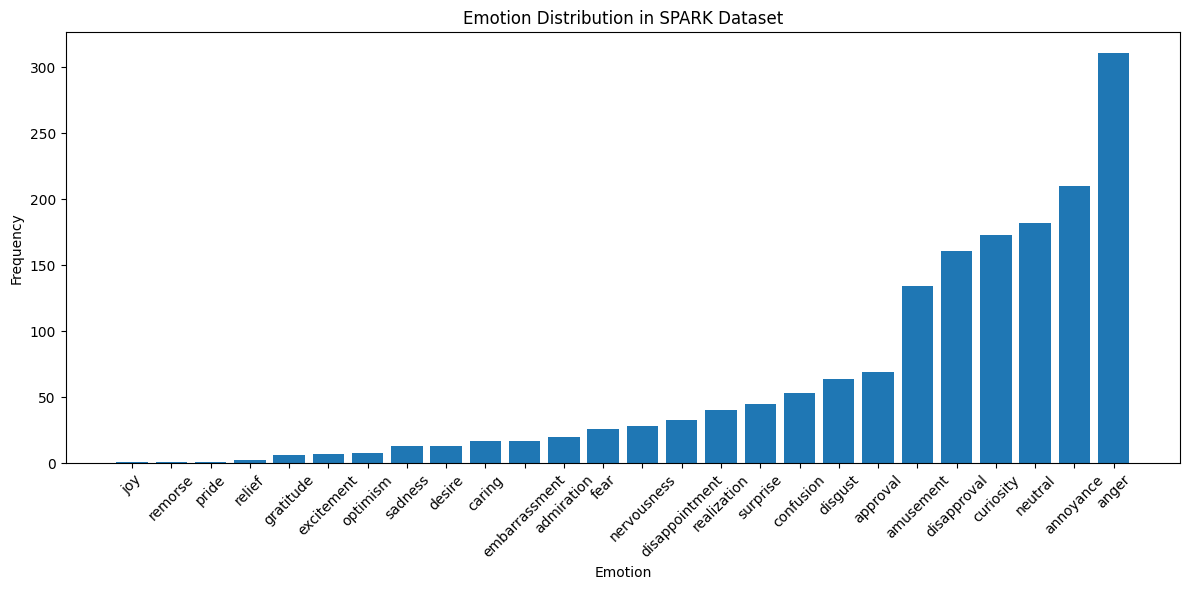

In [18]:
# EDA - Emotion distribution analysis
emotion_counter = Counter(spark_df['emotion'])
emotion_counter_sorted = dict(sorted(emotion_counter.items(), key=lambda x: x[1]))

labels = list(emotion_counter_sorted.keys())
values = list(emotion_counter_sorted.values())

plt.figure(figsize=(12, 6))
plt.bar(labels, values)
plt.title('Emotion Distribution in SPARK Dataset')
plt.xlabel('Emotion')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('spark_emotion_distribution.png', dpi=300)
plt.show()

/var/folders/1k/9zscxwr53576ysrq8v5ym4qc0000gn/T/ipykernel_61204/949959003.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(labels, rotation=90)
/var/folders/1k/9zscxwr53576ysrq8v5ym4qc0000gn/T/ipykernel_61204/949959003.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(labels, rotation=90)


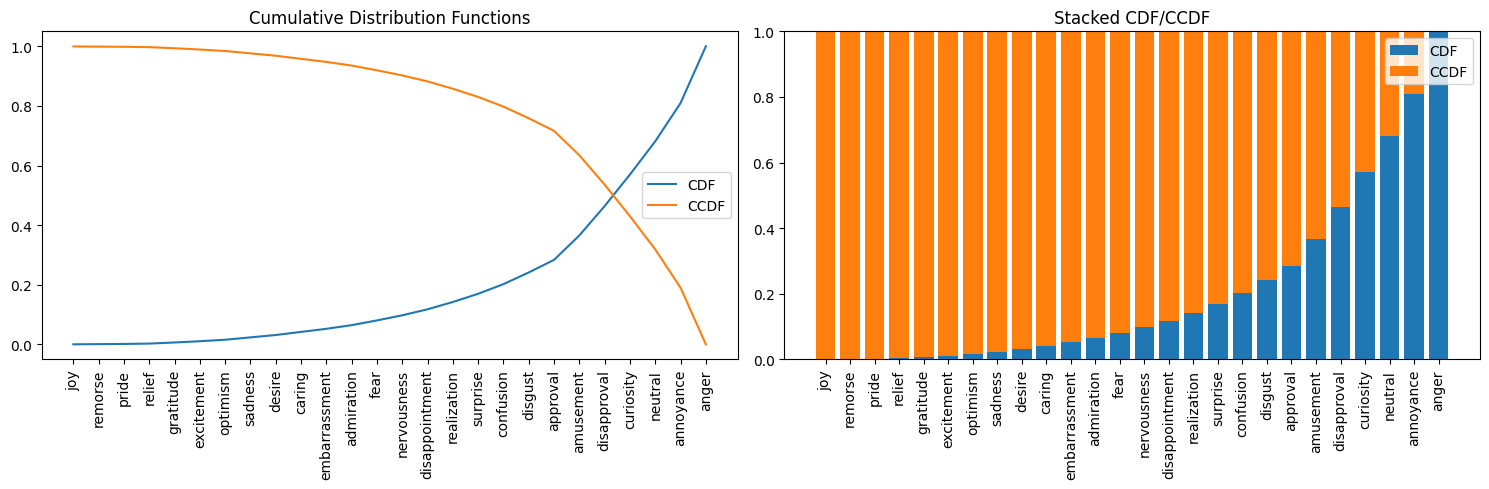

In [19]:
# Cumulative distribution
cdf = np.cumsum(values) / np.sum(values)
ccdf = 1 - cdf

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(15, 5))

ax1.plot(labels, cdf, label='CDF')
ax1.plot(labels, ccdf, label='CCDF')
ax1.set_xticklabels(labels, rotation=90)
ax1.set_title('Cumulative Distribution Functions')
ax1.legend()

ax2.bar(labels, cdf, label='CDF')
ax2.bar(labels, ccdf, bottom=cdf, label='CCDF')
ax2.set_xticklabels(labels, rotation=90)
ax2.set_title('Stacked CDF/CCDF')
ax2.legend()

plt.tight_layout()
plt.savefig('spark_emotion_cdf.png', dpi=300)
plt.show()

Topic distribution:
topic_label
Venting                 539
People                  465
Others                  253
Punishment              160
North Korea             121
Politics & Economics     97
Name: count, dtype: int64


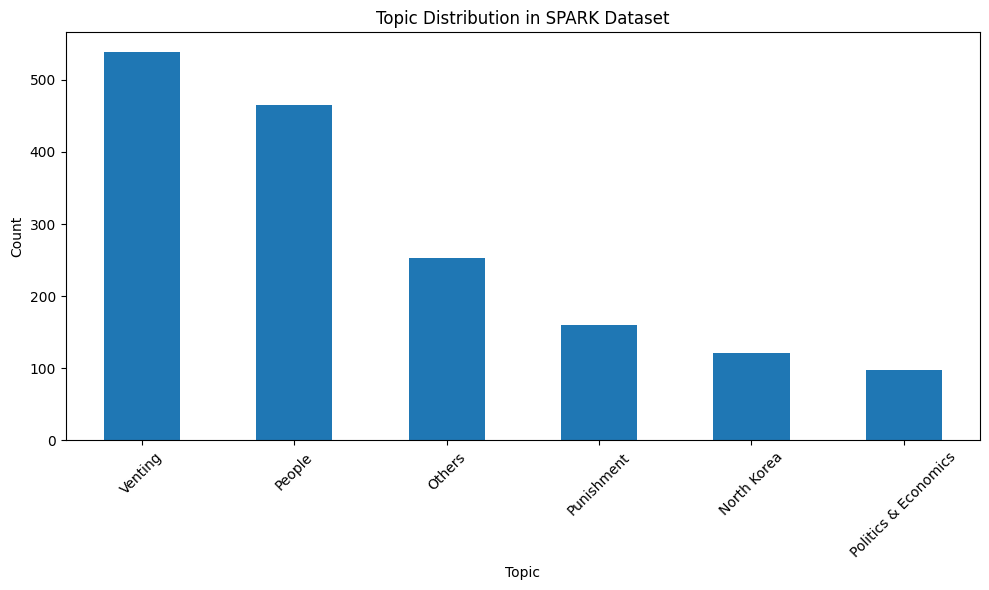

In [20]:
# Topic analysis
topic_counts = spark_df['topic_label'].value_counts()
print("Topic distribution:")
print(topic_counts)

plt.figure(figsize=(10, 6))
topic_counts.plot(kind='bar')
plt.title('Topic Distribution in SPARK Dataset')
plt.xlabel('Topic')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('spark_topic_distribution.png', dpi=300)
plt.show()

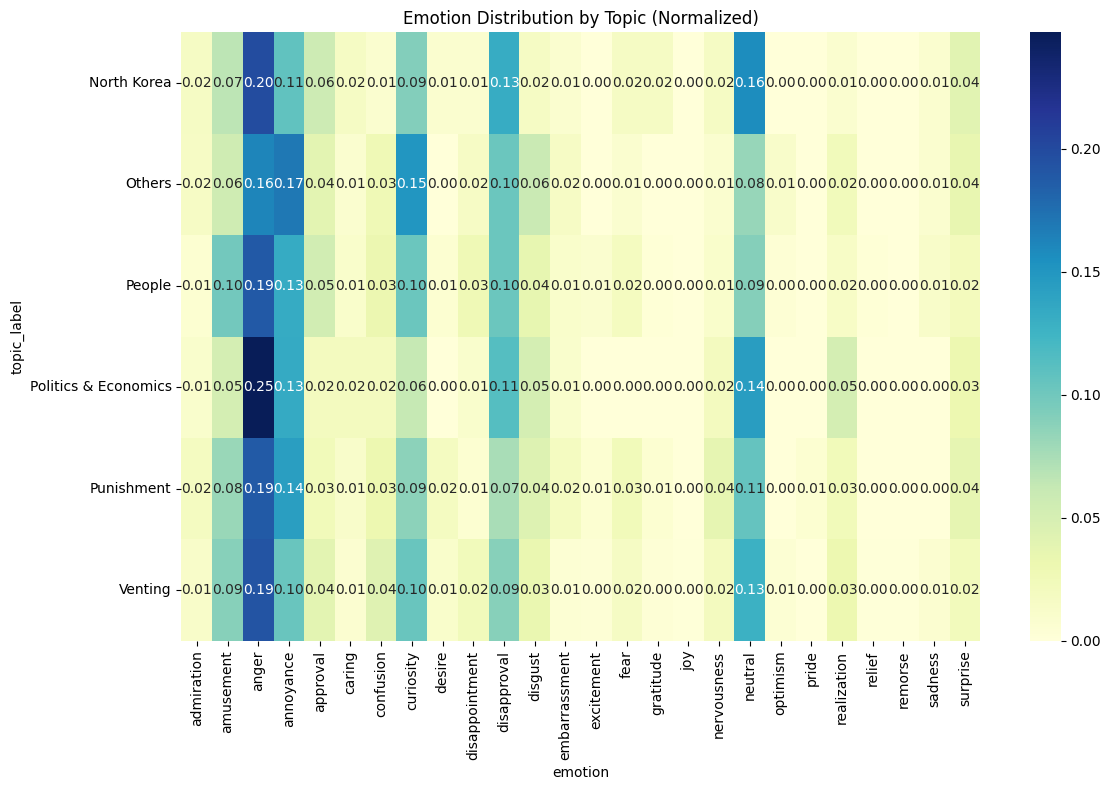

In [21]:
# Cross-tabulation of topics and emotions
topic_emotion_crosstab = pd.crosstab(spark_df['topic_label'], spark_df['emotion'], normalize='index')

plt.figure(figsize=(12, 8))
sns.heatmap(topic_emotion_crosstab, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Emotion Distribution by Topic (Normalized)')
plt.tight_layout()
plt.savefig('spark_topic_emotion_heatmap.png', dpi=300)
plt.show()